# 출퇴근 스트레스 점수 산출 파이프라인 v2

## 문헌 근거 (로지스틱 회귀분석 결과 반영)

연령·성별·직업·소득·사업장규모·교대근무·주근로시간 보정 후, 왕복 출퇴근 소요시간 30분 이하 대비:

| 왕복 소요시간 | 주관적 우울 OR | 불안 OR | 전신 피로 OR |
|------------|--------------|--------|-------------|
| ≤ 30분 (기준) | 1.00 | 1.00 | 1.00 |
| 30 ~ 60분 | - (n.s.) | - (n.s.) | **1.17** (1.08-1.27) |
| 60 ~ 120분 | **1.33** (1.17-1.51) | **1.35** (1.09-1.67) | **1.39** (1.23-1.58) |
| > 120분 | **1.47** (1.07-2.00) | **2.03** (1.39-2.95) | **2.12** (1.56-2.87) |

연구 대상: 37,874명 중 우울 8,828명(23.3%), 불안 2,139명(5.6%), 전신피로 10,015명(26.4%)

→ 유병률 가중 복합 OR을 출퇴근 시간대 스트레스 가중치로 사용


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 상수 및 매핑 테이블

In [16]:
# ── 서울 자치구 매핑 (행정동코드 앞 5자리 → 자치구명) ──────────────────────
SEOUL_GU_MAP = {
    '11010': '종로구', '11020': '중구',      '11030': '용산구',
    '11040': '성동구', '11050': '광진구',    '11060': '동대문구',
    '11070': '중랑구', '11080': '성북구',    '11090': '강북구',
    '11100': '도봉구', '11110': '노원구',    '11120': '은평구',
    '11130': '서대문구','11140': '마포구',   '11150': '양천구',
    '11160': '강서구', '11170': '구로구',    '11180': '금천구',
    '11190': '영등포구','11200': '동작구',   '11210': '관악구',
    '11220': '서초구', '11230': '강남구',    '11240': '송파구',
    '11250': '강동구',
}

SIDO_MAP = {
    '11': '서울', '21': '부산', '22': '대구', '23': '인천',
    '24': '광주', '25': '대전', '26': '울산', '29': '세종',
    '31': '경기', '32': '강원', '33': '충북', '34': '충남',
    '35': '전북', '36': '전남', '37': '경북', '38': '경남', '39': '제주',
    '41': '경기', '42': '강원', '43': '충북', '44': '충남',
    '45': '전북', '46': '전남', '47': '경북', '48': '경남', '50': '제주',
}

TRIP_TYPE_LABELS = {
    'HW': '집→직장(출근)', 'WH': '직장→집(퇴근)',
    'HE': '집→기타',       'EH': '기타→집',
    'WE': '직장→기타',     'EW': '기타→직장',
    'HH': '집→집',         'WW': '직장→직장', 'EE': '기타→기타',
}

TRIP_WEIGHT = {
    'HW': 1.00, 'WH': 1.00,
    'EW': 0.80, 'EH': 0.80,
    'HE': 0.60, 'WE': 0.60,
    'HH': 0.40, 'WW': 0.40, 'EE': 0.40,
}

def get_peak_weight(hour: int) -> float:
    if 7 <= hour < 9 or 18 <= hour < 21:
        return 1.50
    if 6 <= hour < 7 or 9 <= hour < 10 or 17 <= hour < 18 or 21 <= hour < 22:
        return 1.20
    return 1.00

print("✓ 기본 매핑 테이블 로드 완료")

✓ 기본 매핑 테이블 로드 완료


## 2. 문헌 기반 출퇴근 시간대 OR 가중치

유병률 가중 복합 OR 계산:
- 우울(23.3%), 불안(5.6%), 전신피로(26.4%) → 정규화 후 가중 평균

In [17]:
# ── 문헌에서 추출한 OR 테이블 ─────────────────────────────────────────────────
# 참조군: 왕복 출퇴근 소요시간 ≤30분
# n.s.(유의하지 않음)는 기준값 1.00으로 처리
OR_TABLE = {
    '≤30min':    {'depression': 1.00, 'anxiety': 1.00, 'fatigue': 1.00},
    '30-60min':  {'depression': 1.00, 'anxiety': 1.00, 'fatigue': 1.17},  # 우울/불안 n.s.
    '60-120min': {'depression': 1.33, 'anxiety': 1.35, 'fatigue': 1.39},
    '>120min':   {'depression': 1.47, 'anxiety': 2.03, 'fatigue': 2.12},
}

# ── 연구 대상 유병률 (가중치 산출 기준) ─────────────────────────────────────
N_TOTAL = 37_874
PREVALENCE = {
    'depression': 8_828 / N_TOTAL,   # 23.3%
    'anxiety':    2_139 / N_TOTAL,   # 5.6%
    'fatigue':   10_015 / N_TOTAL,   # 26.4%
}
total_prev = sum(PREVALENCE.values())
PREV_WEIGHT = {k: v / total_prev for k, v in PREVALENCE.items()}  # 합계 = 1

# ── 유병률 가중 복합 OR 계산 ──────────────────────────────────────────────────
def composite_or(bracket: str) -> float:
    ors = OR_TABLE[bracket]
    return sum(PREV_WEIGHT[outcome] * ors[outcome] for outcome in PREV_WEIGHT)

LITERATURE_WEIGHT = {bracket: round(composite_or(bracket), 4) for bracket in OR_TABLE}

print("[문헌 기반 복합 OR 가중치]")
print(f"  유병률 가중치: 우울={PREV_WEIGHT['depression']:.3f}, "
      f"불안={PREV_WEIGHT['anxiety']:.3f}, 피로={PREV_WEIGHT['fatigue']:.3f}")
print()
for bracket, w in LITERATURE_WEIGHT.items():
    ors = OR_TABLE[bracket]
    print(f"  {bracket:12s}: 복합OR={w:.4f}  "
          f"(우울={ors['depression']:.2f}, 불안={ors['anxiety']:.2f}, 피로={ors['fatigue']:.2f})")

[문헌 기반 복합 OR 가중치]
  유병률 가중치: 우울=0.421, 불안=0.102, 피로=0.477

  ≤30min      : 복합OR=1.0000  (우울=1.00, 불안=1.00, 피로=1.00)
  30-60min    : 복합OR=1.0811  (우울=1.00, 불안=1.00, 피로=1.17)
  60-120min   : 복합OR=1.3607  (우울=1.33, 불안=1.35, 피로=1.39)
  >120min     : 복합OR=1.8373  (우울=1.47, 불안=2.03, 피로=2.12)


In [18]:
# ── 왕복 출퇴근 소요시간 추정 및 구간 분류 ───────────────────────────────────
# mvmn_dstc(m)를 평균 대중교통 속도로 나누어 편도 시간(분) 추정 → 왕복 = ×2
# 기본 속도: 25 km/h = 416.7 m/min (도심 대중교통 평균 속도)

DEFAULT_TRANSIT_SPEED_M_PER_MIN = 416.7  # 25 km/h

BRACKET_ORDER = ['≤30min', '30-60min', '60-120min', '>120min']

def assign_commute_bracket(
    distance_m: float,
    speed_m_per_min: float = DEFAULT_TRANSIT_SPEED_M_PER_MIN
) -> str:
    """
    이동거리(m)로 왕복 출퇴근 소요시간 구간을 추정합니다.
    
    왕복시간(분) = (거리 / 속도) × 2
    """
    roundtrip_min = (distance_m / speed_m_per_min) * 2
    if roundtrip_min <= 30:
        return '≤30min'
    elif roundtrip_min <= 60:
        return '30-60min'
    elif roundtrip_min <= 120:
        return '60-120min'
    else:
        return '>120min'

# 검증
test_cases = [
    (5_000,  '≤30min   (5km → 왕복 24분)'),
    (10_000, '30-60min (10km → 왕복 48분)'),
    (20_000, '60-120min(20km → 왕복 96분)'),
    (40_000, '>120min  (40km → 왕복 192분)'),
]
print("[구간 분류 검증]")
for dist, label in test_cases:
    bracket = assign_commute_bracket(dist)
    print(f"  {label} → {bracket}")

print("\n[참고] 샘플 데이터의 이동거리 분포")
print("  샘플 데이터는 주로 장거리 이동(>100km)을 포함합니다.")
print("  실제 출퇴근 분석 시, 자치구 내/인접 이동(≤80km 이내)으로 필터를 권장합니다.")

[구간 분류 검증]
  ≤30min   (5km → 왕복 24분) → ≤30min
  30-60min (10km → 왕복 48분) → 30-60min
  60-120min(20km → 왕복 96분) → 60-120min
  >120min  (40km → 왕복 192분) → >120min

[참고] 샘플 데이터의 이동거리 분포
  샘플 데이터는 주로 장거리 이동(>100km)을 포함합니다.
  실제 출퇴근 분석 시, 자치구 내/인접 이동(≤80km 이내)으로 필터를 권장합니다.


## 3. 이동 유형 분류 (70% 임계값 규칙)

In [19]:
LEVEL_TYPES = [
    ['HW', 'WH'],
    ['HW', 'WH', 'EW', 'EH'],
]

def classify_trip_coverage(
    df: pd.DataFrame,
    type_col: str = 'start_arv_place_type',
    threshold: float = 0.70
) -> tuple:
    total = len(df)
    counts = df[type_col].value_counts()
    report = {}

    for level, types in enumerate(LEVEL_TYPES, start=1):
        coverage = sum(counts.get(t, 0) for t in types) / total
        report[f'Level {level}'] = {'types': types, 'coverage': round(coverage, 4)}
        if coverage >= threshold:
            report[f'Level {level}']['selected'] = True
            return types, level, coverage, report
        report[f'Level {level}']['selected'] = False

    all_types = counts.index.tolist()
    report['Level 3'] = {'types': all_types, 'coverage': 1.0, 'selected': True}
    return all_types, 3, 1.0, report


def filter_by_trip_type(
    df: pd.DataFrame,
    threshold: float = 0.70,
    type_col: str = 'start_arv_place_type'
) -> pd.DataFrame:
    selected_types, level, coverage, report = classify_trip_coverage(df, type_col, threshold)

    print(f"[이동 유형 분류 결과]")
    for lv, info in report.items():
        marker = ' ← 선택됨' if info.get('selected') else ''
        print(f"  {lv}: {info['types']} | {info['coverage']:.1%}{marker}")

    filtered = df[df[type_col].isin(selected_types)].copy()
    filtered['trip_weight'] = filtered[type_col].map(lambda t: TRIP_WEIGHT.get(t, 0.5))
    filtered['trip_level']  = level
    return filtered

print("✓ 이동 유형 분류 함수 정의 완료")

✓ 이동 유형 분류 함수 정의 완료


## 4. 보조 특성 추출 (자치구 매핑, 시간, 문헌 가중치)

In [20]:
def emd_to_gu(emd_code) -> tuple:
    code_str  = str(int(emd_code)).zfill(7)
    gu_code   = code_str[:5]
    sido_code = code_str[:2]
    if gu_code in SEOUL_GU_MAP:
        return SEOUL_GU_MAP[gu_code], '서울'
    sido_name = SIDO_MAP.get(sido_code, f'기타({sido_code})')
    return f'{sido_name}_{gu_code}', sido_name


def add_gu_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['start_gu'], df['start_sido'] = zip(*df['start_emd'].apply(emd_to_gu))
    df['arv_gu'],   df['arv_sido']   = zip(*df['arv_emd'].apply(emd_to_gu))
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['start_dt']    = pd.to_datetime(df['start_dt'])
    df['arv_dt']      = pd.to_datetime(df['arv_dt'])
    df['start_hour']  = df['start_dt'].dt.hour
    df['start_date']  = df['start_dt'].dt.date
    df['year_month']  = df['start_dt'].dt.to_period('M')   # 월별 집계용
    df['day_of_week'] = df['start_dt'].dt.dayofweek
    df['is_weekday']  = df['day_of_week'] < 5
    df['peak_weight'] = df['start_hour'].apply(get_peak_weight)
    return df


def add_literature_weight(
    df: pd.DataFrame,
    speed_m_per_min: float = DEFAULT_TRANSIT_SPEED_M_PER_MIN
) -> pd.DataFrame:
    """
    mvmn_dstc(이동거리)로 왕복 출퇴근 시간 구간을 추정하고,
    문헌 기반 복합 OR 가중치(literature_weight)를 추가합니다.
    """
    df = df.copy()
    df['commute_bracket'] = df['mvmn_dstc'].apply(
        lambda d: assign_commute_bracket(d, speed_m_per_min)
    )
    df['literature_weight'] = df['commute_bracket'].map(LITERATURE_WEIGHT)
    return df

print("✓ 특성 추출 함수 정의 완료")

✓ 특성 추출 함수 정의 완료


## 5. 스트레스 점수 산출

```
base_stress   = w_time × percentile_rank(이동시간)
              + w_pop  × log_norm(유동인구)

stress_score  = normalize(
                  peak_weight           ← 시간대 가중치 (첨두 1.5)
                  × trip_weight         ← 이동 유형 가중치 (HW/WH=1.0)
                  × literature_weight   ← 문헌 기반 복합 OR
                  × base_stress
                ) × 100
```

In [21]:
def percentile_normalize(series: pd.Series) -> pd.Series:
    return series.rank(pct=True)

def log_minmax_normalize(series: pd.Series) -> pd.Series:
    log_vals = np.log1p(series)
    denom = log_vals.max() - log_vals.min()
    if denom == 0:
        return pd.Series(0.0, index=series.index)
    return (log_vals - log_vals.min()) / denom


def calculate_stress_scores(
    df: pd.DataFrame,
    w_time: float = 0.5,
    w_pop:  float = 0.5,
    cap_pct: float = 0.99
) -> pd.DataFrame:
    """
    출퇴근 스트레스 점수 산출 (0~100 스케일)

    가중치 구조
    -----------
    peak_weight       : 시간대 (첨두=1.5, 어깨=1.2, 비첨두=1.0)
    trip_weight       : 이동 유형 (HW/WH=1.0, EW/EH=0.8, 기타=0.4)
    literature_weight : 문헌 복합 OR (≤30=1.000, 30-60=1.081,
                                      60-120=1.361, >120=1.838)
    """
    df = df.copy()
    df['travel_stress'] = percentile_normalize(df['mvmn_time_sum'])
    df['congestion']    = log_minmax_normalize(df['popl_cnt'])
    df['base_stress']   = w_time * df['travel_stress'] + w_pop * df['congestion']

    df['raw_score'] = (
        df['peak_weight']
        * df['trip_weight']
        * df['literature_weight']
        * df['base_stress']
    )

    cap_val = df['raw_score'].quantile(cap_pct)
    df['stress_score'] = (df['raw_score'] / cap_val * 100).clip(upper=100).round(2)
    return df

print("✓ 스트레스 점수 산출 함수 정의 완료")

✓ 스트레스 점수 산출 함수 정의 완료


## 6. 집계 함수 (자치구별 / 월별)

In [22]:
def aggregate_by_district(
    df: pd.DataFrame,
    group_by: str = 'arv_gu',
    seoul_only: bool = True
) -> pd.DataFrame:
    if seoul_only:
        sido_col = 'arv_sido' if group_by == 'arv_gu' else 'start_sido'
        df = df[df[sido_col] == '서울']

    agg = (
        df.groupby(group_by)
        .agg(
            avg_stress      = ('stress_score',      'mean'),
            median_stress   = ('stress_score',      'median'),
            p90_stress      = ('stress_score',      lambda x: x.quantile(0.9)),
            trip_count      = ('stress_score',      'count'),
            avg_travel_min  = ('mvmn_time_sum',     'mean'),
            avg_population  = ('popl_cnt',          'mean'),
            peak_ratio      = ('peak_weight',       lambda x: (x > 1.0).mean()),
            bracket_120plus = ('commute_bracket',   lambda x: (x == '>120min').mean()),
        )
        .round(3)
        .sort_values('avg_stress', ascending=False)
        .rename_axis('자치구')
    )
    agg.columns = [
        '평균스트레스', '중앙값스트레스', '90분위스트레스',
        '이동건수', '평균이동시간', '평균유동인구',
        '첨두시간비율', '장거리통근비율(>120min)'
    ]
    return agg


def aggregate_by_month(
    df: pd.DataFrame,
    seoul_only: bool = True
) -> pd.DataFrame:
    """
    year_month 단위로 월별 스트레스 점수를 집계합니다.
    2022~2024년 36개월 데이터에 적용하도록 설계.
    """
    if seoul_only:
        df = df[df['arv_sido'] == '서울']

    monthly = (
        df.groupby('year_month')
        .agg(
            avg_stress      = ('stress_score',    'mean'),
            median_stress   = ('stress_score',    'median'),
            p90_stress      = ('stress_score',    lambda x: x.quantile(0.9)),
            trip_count      = ('stress_score',    'count'),
            avg_travel_min  = ('mvmn_time_sum',   'mean'),
            avg_population  = ('popl_cnt',        'mean'),
            peak_ratio      = ('peak_weight',     lambda x: (x > 1.0).mean()),
            lit_weight_avg  = ('literature_weight','mean'),
        )
        .round(3)
    )
    monthly.columns = [
        '평균스트레스', '중앙값스트레스', '90분위스트레스',
        '이동건수', '평균이동시간', '평균유동인구',
        '첨두시간비율', '평균문헌가중치'
    ]
    monthly.index = monthly.index.astype(str)
    return monthly


def aggregate_monthly_by_district(
    df: pd.DataFrame,
    seoul_only: bool = True
) -> pd.DataFrame:
    """월 × 자치구 교차 집계 (히트맵용)"""
    if seoul_only:
        df = df[df['arv_sido'] == '서울']

    cross = (
        df.groupby(['year_month', 'arv_gu'])['stress_score']
        .mean()
        .unstack('arv_gu')
        .round(2)
    )
    cross.index = cross.index.astype(str)
    return cross

print("✓ 집계 함수 정의 완료 (자치구별 / 월별 / 월×자치구 교차)")

✓ 집계 함수 정의 완료 (자치구별 / 월별 / 월×자치구 교차)


## 7. 전체 파이프라인 함수

In [23]:
# ── 연도 필터 설정 ─────────────────────────────────────────────────────────────
# 테스트: 샘플 데이터(2019년)
# 실전:  2022~2024년 (36개월)
TEST_YEARS  = [2019]
PROD_YEARS  = [2022, 2023, 2024]


def run_commute_stress_pipeline(
    source,
    target_years: list   = None,   # None이면 전체 연도 사용
    threshold:    float  = 0.70,
    w_time:       float  = 0.5,
    w_pop:        float  = 0.5,
    weekday_only: bool   = False,
    speed_m_per_min: float = DEFAULT_TRANSIT_SPEED_M_PER_MIN,
    encoding:     str    = 'utf-8',
) -> dict:
    """
    출퇴근 스트레스 점수 산출 파이프라인 (문헌 OR 가중치 포함)

    Parameters
    ----------
    source          : CSV 파일경로(str) 또는 DataFrame
    target_years    : 분석 연도 리스트. 예) [2019] 또는 [2022,2023,2024]
    threshold       : 이동 유형 70% 임계값
    w_time / w_pop  : 이동시간/유동인구 가중치 (합계 = 1 권장)
    weekday_only    : True이면 평일 데이터만 사용
    speed_m_per_min : 왕복시간 추정용 평균 속도 (기본 416.7 m/min = 25 km/h)

    Returns
    -------
    dict: 'records', 'monthly', 'district', 'monthly_district', 'trip_level'
    """
    SEP = '=' * 65
    print(SEP)
    print("  서울시 출퇴근 스트레스 점수 산출 파이프라인 (문헌 가중치 포함)")
    print(SEP)

    # Step 1: 로딩
    print("\n[Step 1] 데이터 로딩")
    if isinstance(source, str):
        df = pd.read_csv(source, encoding=encoding)
    else:
        df = source.copy()
    df['start_dt'] = pd.to_datetime(df['start_dt'])
    df['arv_dt']   = pd.to_datetime(df['arv_dt'])
    print(f"  원본 레코드: {len(df):,}건")

    # Step 2: 연도 필터
    if target_years:
        df = df[df['start_dt'].dt.year.isin(target_years)].copy()
        print(f"  연도 필터 ({target_years}) 적용 후: {len(df):,}건")

    # Step 3: 이동 유형 필터링
    print("\n[Step 2] 이동 유형 분류")
    df = filter_by_trip_type(df, threshold=threshold)
    trip_level = int(df['trip_level'].iloc[0])

    # Step 4: 시간 특성
    print("\n[Step 3] 시간 특성 추출")
    df = add_time_features(df)
    if weekday_only:
        df = df[df['is_weekday']].copy()
        print(f"  평일 필터 후: {len(df):,}건")

    # Step 5: 자치구 매핑
    print("\n[Step 4] 행정동 → 자치구 매핑")
    df = add_gu_columns(df)
    print(f"  도착지 서울 비율: {(df['arv_sido']=='서울').mean():.1%}")

    # Step 6: 문헌 가중치
    print("\n[Step 5] 문헌 기반 출퇴근 구간 가중치 적용")
    df = add_literature_weight(df, speed_m_per_min)
    bracket_dist = df['commute_bracket'].value_counts(normalize=True)
    for bracket in BRACKET_ORDER:
        ratio = bracket_dist.get(bracket, 0)
        w = LITERATURE_WEIGHT[bracket]
        print(f"  {bracket:12s}: {ratio:.1%}  (OR가중치={w:.3f})")

    # Step 7: 스트레스 점수
    print("\n[Step 6] 스트레스 점수 산출")
    df = calculate_stress_scores(df, w_time=w_time, w_pop=w_pop)
    print(f"  평균={df['stress_score'].mean():.1f}  "
          f"중앙값={df['stress_score'].median():.1f}  "
          f"최대={df['stress_score'].max():.1f}")

    # Step 8: 집계
    print("\n[Step 7] 집계")
    monthly_df  = aggregate_by_month(df)
    district_df = aggregate_by_district(df)
    monthly_gu_df = aggregate_monthly_by_district(df)

    print(f"  → 월별 집계: {len(monthly_df)}개월")
    print(f"  → 자치구별 집계: {len(district_df)}개 자치구")
    print(f"\n{SEP}")

    return {
        'records':          df,
        'monthly':          monthly_df,
        'district':         district_df,
        'monthly_district': monthly_gu_df,
        'trip_level':       trip_level,
    }

print("✓ 전체 파이프라인 함수 정의 완료")

✓ 전체 파이프라인 함수 정의 완료


---
## 8. 테스트 실행 (샘플 데이터 2019년)

> 실전 전환 시: `target_years = PROD_YEARS` (2022~2024, 36개월)

In [24]:
SAMPLE_PATH = '../20191001_OUTPUT.csv'

result = run_commute_stress_pipeline(
    source       = SAMPLE_PATH,
    target_years = TEST_YEARS,   # 테스트: [2019]  /  실전: PROD_YEARS
    threshold    = 0.70,
    w_time       = 0.5,
    w_pop        = 0.5,
    weekday_only = False,
)

  서울시 출퇴근 스트레스 점수 산출 파이프라인 (문헌 가중치 포함)

[Step 1] 데이터 로딩
  원본 레코드: 400건
  연도 필터 ([2019]) 적용 후: 400건

[Step 2] 이동 유형 분류
[이동 유형 분류 결과]
  Level 1: ['HW', 'WH'] | 1.5%
  Level 2: ['HW', 'WH', 'EW', 'EH'] | 24.5%
  Level 3: ['EE', 'HE', 'EH', 'EW', 'WE', 'HH', 'WH', 'HW', 'WW'] | 100.0% ← 선택됨

[Step 3] 시간 특성 추출

[Step 4] 행정동 → 자치구 매핑
  도착지 서울 비율: 37.0%

[Step 5] 문헌 기반 출퇴근 구간 가중치 적용
  ≤30min      : 0.0%  (OR가중치=1.000)
  30-60min    : 0.0%  (OR가중치=1.081)
  60-120min   : 0.0%  (OR가중치=1.361)
  >120min     : 100.0%  (OR가중치=1.837)

[Step 6] 스트레스 점수 산출
  평균=36.5  중앙값=32.8  최대=100.0

[Step 7] 집계
  → 월별 집계: 1개월
  → 자치구별 집계: 25개 자치구



In [25]:
df_result   = result['records']
df_monthly  = result['monthly']
df_district = result['district']

print("[월별 스트레스 점수]")
display(df_monthly)

print("\n[자치구별 스트레스 점수 (상위 10개)]")
display(df_district.head(10))

[월별 스트레스 점수]


,평균스트레스,중앙값스트레스,90분위스트레스,이동건수,평균이동시간,평균유동인구,첨두시간비율,평균문헌가중치
year_month,,,,,,,,
2019-09,38.771,36.875,70.179,148,1147.115,3.278,0.365,1.837



[자치구별 스트레스 점수 (상위 10개)]


,평균스트레스,중앙값스트레스,90분위스트레스,이동건수,평균이동시간,평균유동인구,첨두시간비율,장거리통근비율(>120min)
자치구,,,,,,,,
중랑구,57.170,51.950,78.206,5,1305.600,3.210,0.800,1.0
서대문구,55.890,55.890,67.194,2,1273.500,4.375,0.500,1.0
양천구,50.562,46.605,87.820,8,1259.750,2.830,0.625,1.0
용산구,49.613,47.975,87.410,6,1151.833,3.028,0.333,1.0
성북구,48.506,49.430,70.270,7,1092.429,3.753,0.857,1.0
마포구,46.776,56.560,68.988,5,1212.200,3.004,0.000,1.0
성동구,45.128,47.075,74.120,6,1142.667,2.912,0.333,1.0
중구,43.254,38.490,57.700,7,1228.286,3.306,0.429,1.0
동작구,43.227,52.770,61.081,10,1097.300,2.930,0.600,1.0


## 9. 시각화

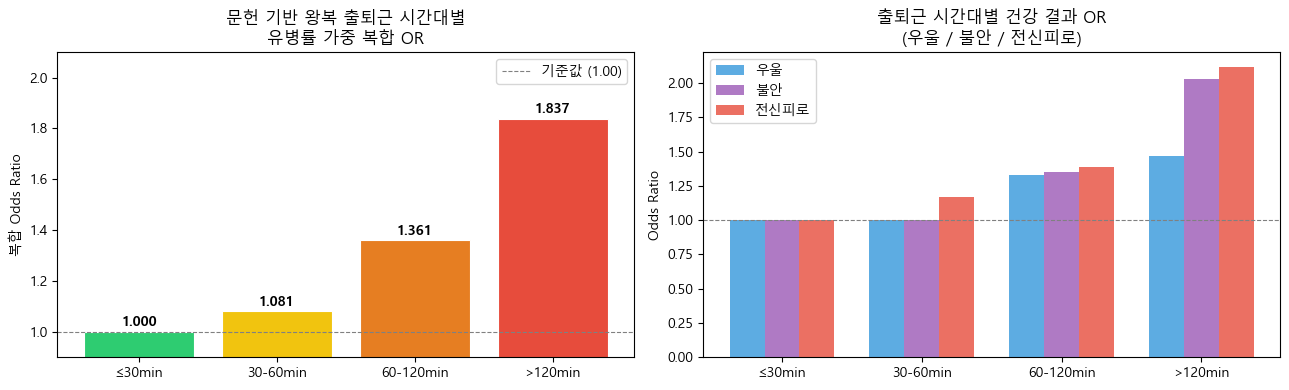

In [26]:
# ── (1) 문헌 가중치 구조 시각화 ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 복합 OR 가중치 막대그래프
brackets = list(LITERATURE_WEIGHT.keys())
weights  = list(LITERATURE_WEIGHT.values())
colors   = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = axes[0].bar(brackets, weights, color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='기준값 (1.00)')
for bar, w in zip(bars, weights):
    axes[0].text(bar.get_x() + bar.get_width()/2, w + 0.01, f'{w:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0.9, 2.1)
axes[0].set_ylabel('복합 Odds Ratio')
axes[0].set_title('문헌 기반 왕복 출퇴근 시간대별\n유병률 가중 복합 OR')
axes[0].legend()

# 개별 OR 비교
x = np.arange(len(brackets))
width = 0.25
outcomes = ['depression', 'anxiety', 'fatigue']
outcome_labels = ['우울', '불안', '전신피로']
outcome_colors = ['#3498db', '#9b59b6', '#e74c3c']
for i, (outcome, label, color) in enumerate(zip(outcomes, outcome_labels, outcome_colors)):
    ors = [OR_TABLE[b][outcome] for b in brackets]
    axes[1].bar(x + i*width, ors, width, label=label, color=color, alpha=0.8)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(brackets)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Odds Ratio')
axes[1].set_title('출퇴근 시간대별 건강 결과 OR\n(우울 / 불안 / 전신피로)')
axes[1].legend()

plt.tight_layout()
plt.show()

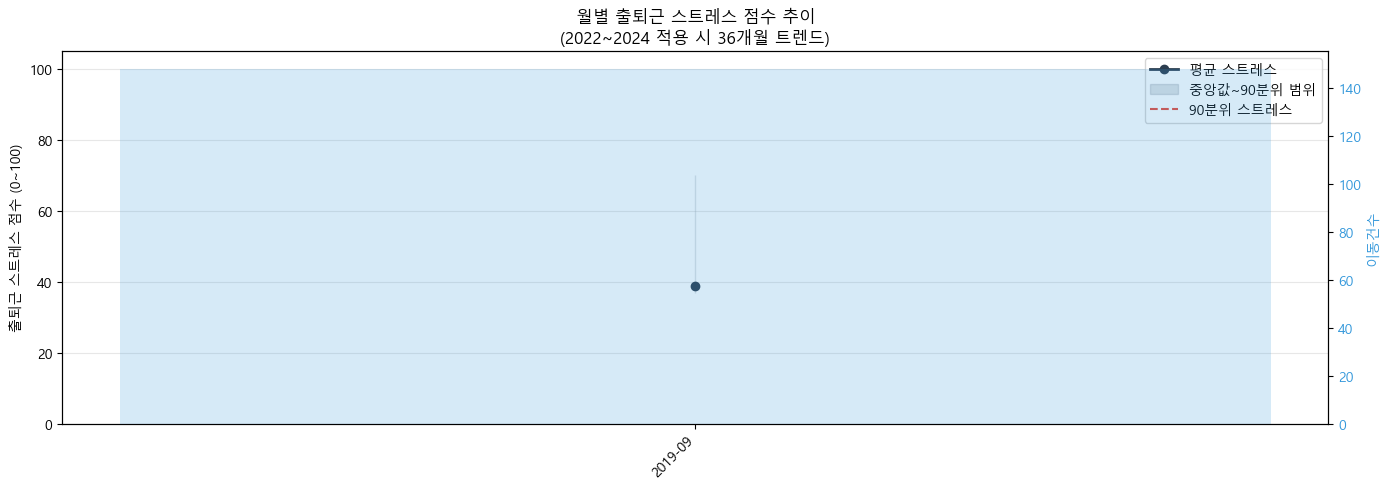

※ 샘플 데이터는 1개월치(2019-09)로 트렌드 분석은 2022~2024 실전 데이터에서 의미 있습니다.


In [27]:
# ── (2) 월별 스트레스 점수 트렌드 ────────────────────────────────────────────
# 샘플은 1개월치만 있으므로, 실전(36개월)에서 의미 있게 보임

fig, ax = plt.subplots(figsize=(14, 5))

months = df_monthly.index.tolist()
ax.plot(months, df_monthly['평균스트레스'], marker='o', color='#2c3e50',
        linewidth=2, markersize=6, label='평균 스트레스')
ax.fill_between(months,
                df_monthly['중앙값스트레스'],
                df_monthly['90분위스트레스'],
                alpha=0.15, color='#2c3e50', label='중앙값~90분위 범위')
ax.plot(months, df_monthly['90분위스트레스'], linestyle='--', color='#e74c3c',
        linewidth=1.5, label='90분위 스트레스')

ax.set_ylabel('출퇴근 스트레스 점수 (0~100)')
ax.set_title('월별 출퇴근 스트레스 점수 추이\n(2022~2024 적용 시 36개월 트렌드)')
ax.legend(loc='upper right')
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45, ha='right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# 이동건수를 보조축에 표시
ax2 = ax.twinx()
ax2.bar(range(len(months)), df_monthly['이동건수'],
        alpha=0.2, color='#3498db', label='이동건수')
ax2.set_ylabel('이동건수', color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')

plt.tight_layout()
plt.show()
print("※ 샘플 데이터는 1개월치(2019-09)로 트렌드 분석은 2022~2024 실전 데이터에서 의미 있습니다.")

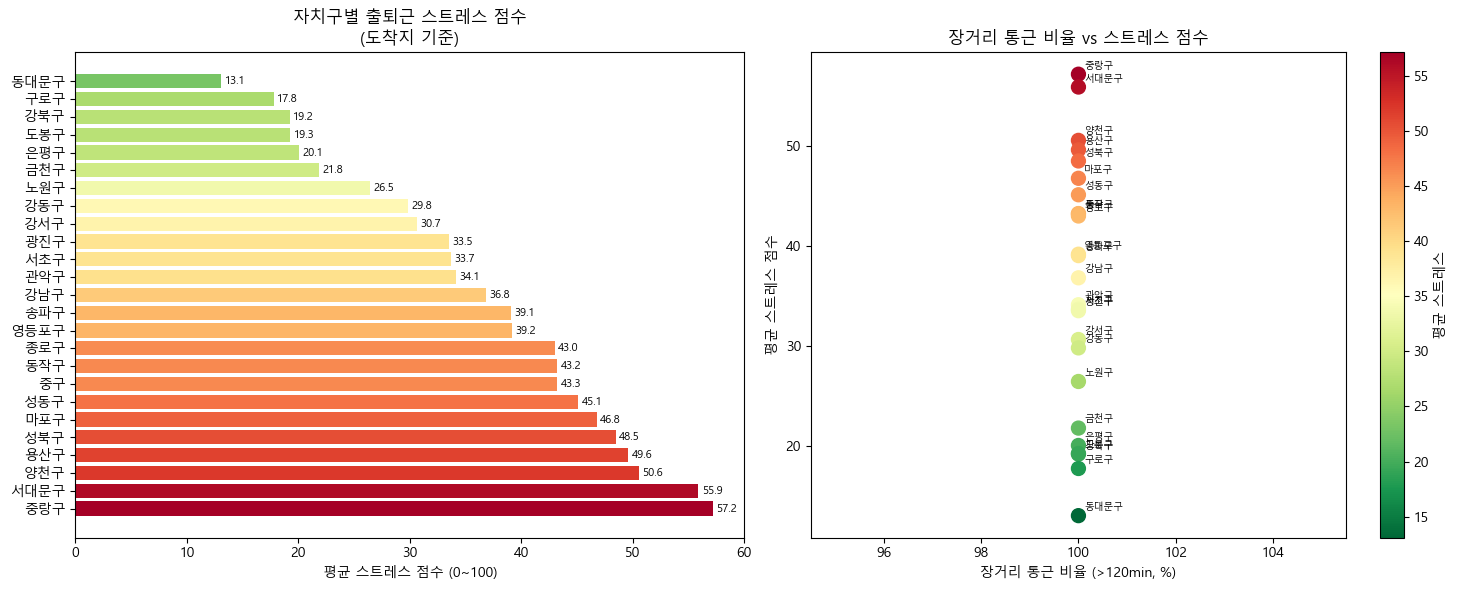

In [28]:
# ── (3) 자치구별 스트레스 점수 + 장거리통근 비율 ─────────────────────────────
if len(df_district) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 자치구별 평균 스트레스 (수평 막대)
    cmap_vals = df_district['평균스트레스'] / df_district['평균스트레스'].max()
    bar_colors = plt.cm.RdYlGn_r(cmap_vals)
    bars = axes[0].barh(df_district.index, df_district['평균스트레스'], color=bar_colors)
    for bar, val in zip(bars, df_district['평균스트레스']):
        axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}', va='center', fontsize=8)
    axes[0].set_xlabel('평균 스트레스 점수 (0~100)')
    axes[0].set_title('자치구별 출퇴근 스트레스 점수\n(도착지 기준)')

    # 장거리 통근 비율 vs 스트레스 산포도
    scatter = axes[1].scatter(
        df_district['장거리통근비율(>120min)'] * 100,
        df_district['평균스트레스'],
        c=df_district['평균스트레스'],
        cmap='RdYlGn_r', s=100, zorder=5
    )
    for gu, row in df_district.iterrows():
        axes[1].annotate(gu,
            (row['장거리통근비율(>120min)']*100, row['평균스트레스']),
            textcoords='offset points', xytext=(4, 4), fontsize=7)
    axes[1].set_xlabel('장거리 통근 비율 (>120min, %)')
    axes[1].set_ylabel('평균 스트레스 점수')
    axes[1].set_title('장거리 통근 비율 vs 스트레스 점수')
    plt.colorbar(scatter, ax=axes[1], label='평균 스트레스')

    plt.tight_layout()
    plt.show()

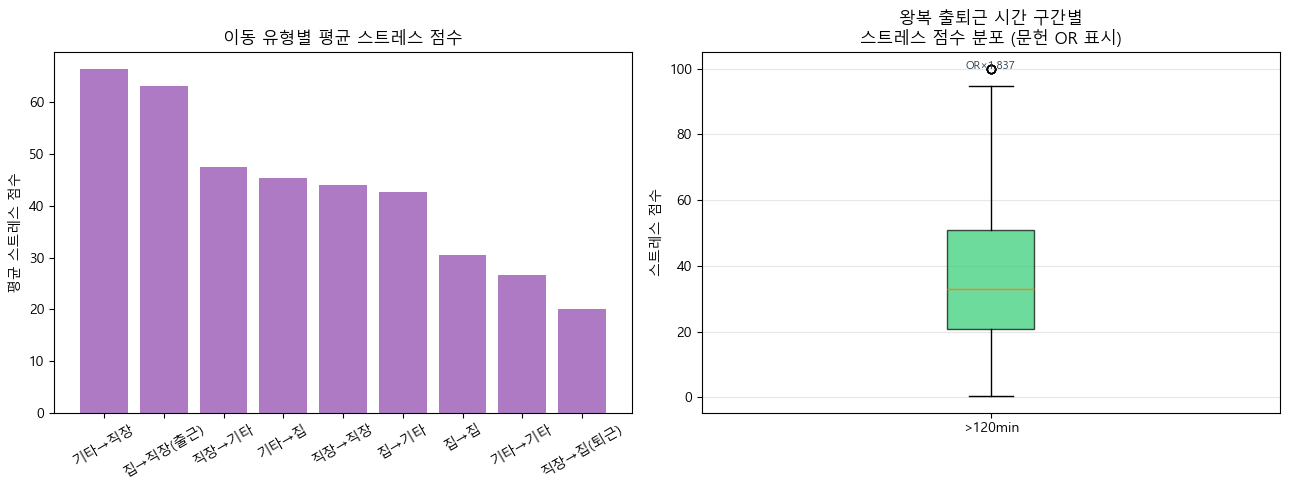

In [29]:
# ── (4) 이동 유형 구성 및 구간별 스트레스 분포 ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 이동 유형별 평균 스트레스
type_stress = (
    df_result.groupby('start_arv_place_type')['stress_score'].mean()
    .sort_values(ascending=False)
)
axes[0].bar(
    [TRIP_TYPE_LABELS.get(t, t) for t in type_stress.index],
    type_stress.values,
    color='#9b59b6', alpha=0.8
)
axes[0].set_ylabel('평균 스트레스 점수')
axes[0].set_title('이동 유형별 평균 스트레스 점수')
axes[0].tick_params(axis='x', rotation=30)

# 출퇴근 구간별 스트레스 분포
bracket_order = [b for b in BRACKET_ORDER if b in df_result['commute_bracket'].unique()]
data_by_bracket = [df_result[df_result['commute_bracket'] == b]['stress_score'].values
                   for b in bracket_order]
bplot = axes[1].boxplot(data_by_bracket, labels=bracket_order, patch_artist=True)
for patch, color in zip(bplot['boxes'], ['#2ecc71','#f1c40f','#e67e22','#e74c3c'][:len(bracket_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# OR 가중치 주석 추가
for i, b in enumerate(bracket_order, start=1):
    w = LITERATURE_WEIGHT[b]
    axes[1].text(i, axes[1].get_ylim()[1] * 0.95, f'OR×{w:.3f}',
                ha='center', fontsize=8, color='#2c3e50')

axes[1].set_ylabel('스트레스 점수')
axes[1].set_title('왕복 출퇴근 시간 구간별\n스트레스 점수 분포 (문헌 OR 표시)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. 실전 적용 (2022~2024, 36개월)

아래 셀의 주석을 해제하고 파일 패턴만 변경하면 됩니다.

In [ ]:
import glob

def run_on_multiple_files(file_pattern: str, **kwargs) -> dict:
    """여러 CSV 파일을 합쳐 파이프라인을 실행합니다."""
    files = sorted(glob.glob(file_pattern))
    if not files:
        raise FileNotFoundError(f"패턴 '{file_pattern}' 에 해당하는 파일 없음")
    print(f"[파일 목록] {len(files)}개 파일")
    for f in files[:5]:
        print(f"  {f}")
    if len(files) > 5:
        print(f"  ... 외 {len(files)-5}개")

    enc = kwargs.pop('encoding', 'utf-8')
    df_all = pd.concat(
        [pd.read_csv(f, encoding=enc) for f in files],
        ignore_index=True
    )
    print(f"합산 레코드: {len(df_all):,}건")
    return run_commute_stress_pipeline(df_all, **kwargs)


# ── 실전 사용 예 (주석 해제 후 파일 패턴 설정) ─────────────────────────────
# result_full = run_on_multiple_files(
#     file_pattern = '../data/OUTPUT_*.csv',
#     target_years = PROD_YEARS,           # [2022, 2023, 2024]
#     threshold    = 0.70,
#     w_time       = 0.5,
#     w_pop        = 0.5,
#     weekday_only = True,                 # 평일만 분석
# )
# result_full['monthly'].to_csv('commute_stress_monthly.csv', encoding='utf-8-sig')
# result_full['district'].to_csv('commute_stress_district.csv', encoding='utf-8-sig')

print("✓ 실전 적용 함수 준비 완료")
print("  → 실전 전환 시: target_years=PROD_YEARS, file_pattern 수정 후 주석 해제")

✓ 실전 적용 함수 준비 완료
  → 실전 전환 시: target_years=PROD_YEARS, file_pattern 수정 후 주석 해제


: 

---
## 파이프라인 요약

| 단계 | 내용 |
|------|------|
| 1 | CSV 로딩 (파일 / DataFrame 모두 지원) |
| 2 | **연도 필터** `TEST_YEARS=[2019]` / `PROD_YEARS=[2022,2023,2024]` |
| 3 | **70% 임계값 규칙** HW/WH → (+EW/EH) → 전체 |
| 4 | 시간 특성 추출 (시각, 요일, 첨두 가중치, **year_month**) |
| 5 | 행정동 코드 → 자치구 매핑 |
| 6 | **문헌 OR 가중치** mvmn_dstc → 왕복시간 추정 → 복합OR 할당 |
| 7 | 스트레스 점수 산출 (peak × trip × **lit_weight** × base_stress) |
| 8 | **월별 집계** (36개월 트렌드) + 자치구별 집계 |

### 문헌 복합 OR 가중치
| 왕복 구간 | 복합 OR | 구성 |
|----------|---------|------|
| ≤ 30분 | 1.000 | 기준값 |
| 30 ~ 60분 | 1.081 | 피로 OR 1.17 반영 |
| 60 ~ 120분 | 1.361 | 우울1.33+불안1.35+피로1.39 가중평균 |
| > 120분 | 1.838 | 우울1.47+불안2.03+피로2.12 가중평균 |

### 파라미터 조정 가이드
```python
# 이동시간 더 중시
w_time=0.7, w_pop=0.3

# 더 빠른 도심 속도 가정 (30 km/h)
speed_m_per_min=500

# 출퇴근 통근만 엄격히 분석
weekday_only=True, threshold=0.70
```
